In [1]:
import pandas as pd # data processing
import numpy as np  # linear algebra
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('wine_data.csv',header=None,usecols=[0,1,2])
df.columns = ['Class label', 'Alcohol', 'Malic acid']

In [5]:
df

,Class label,Alcohol,Malic acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59
...,...,...,...
173,3,13.71,5.65
174,3,13.40,3.91
175,3,13.27,4.28
176,3,13.17,2.59


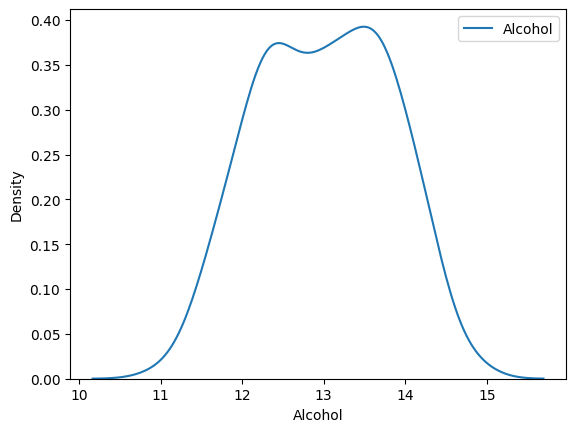

In [17]:
sns.kdeplot(df['Alcohol'], label='Alcohol' )
plt.legend()
plt.show()

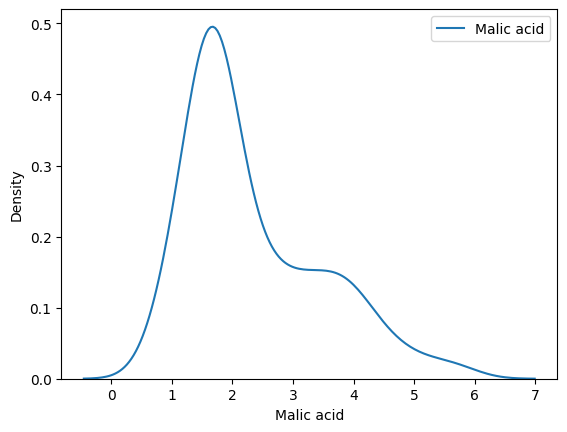

In [18]:
sns.kdeplot(df['Malic acid'], label='Malic acid')
plt.legend()
plt.show()

<Axes: xlabel='Alcohol', ylabel='Malic acid'>

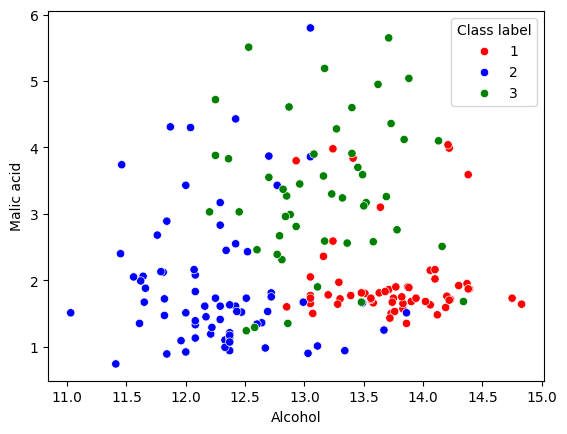

In [25]:
color_dict = {1:'red',2:'blue',3:'green'}
sns.scatterplot(x=df['Alcohol'],y=df['Malic acid'],hue=df['Class label'],palette=color_dict)

# train test split

In [28]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('Class label', axis=1),
                                                   df['Class label'],
                                                   test_size=0.3,
                                                   random_state=0)
X_train.shape ,X_test.shape 

((124, 2), (54, 2))

In [31]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# fit the scaler to the trian set, it will learn the parameters
scaler.fit(X_train)

# transform train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [32]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [33]:
np.round(X_train.describe())

,Alcohol,Malic acid
count,124.0,124.0
mean,13.0,2.0
std,1.0,1.0
min,11.0,1.0
25%,12.0,2.0
50%,13.0,2.0
75%,14.0,3.0
max,15.0,6.0


In [34]:
np.round(X_train_scaled.describe())

,Alcohol,Malic acid
count,124.0,124.0
mean,1.0,0.0
std,0.0,0.0
min,0.0,0.0
25%,0.0,0.0
50%,1.0,0.0
75%,1.0,0.0
max,1.0,1.0


# before Scaling and after scaling scatterplot

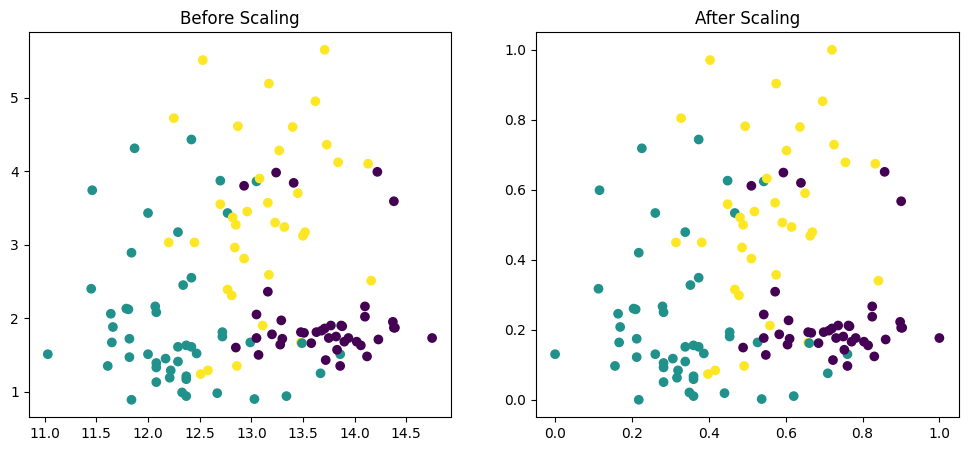

In [37]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train['Alcohol'], X_train['Malic acid'], c=y_train)
ax1.set_title('Before Scaling')

ax2.scatter(X_train_scaled['Alcohol'], X_train_scaled['Malic acid'], c=y_train)
ax2.set_title('After Scaling')

plt.show()

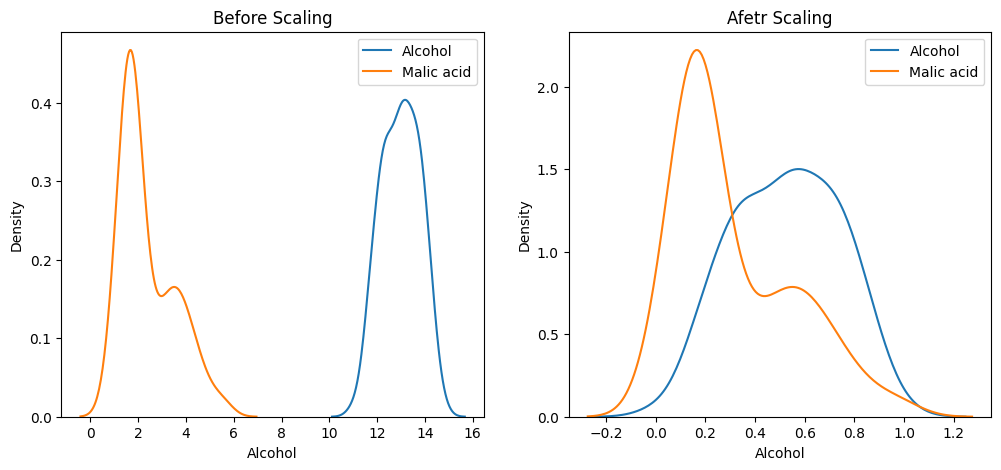

In [41]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Alcohol'], ax=ax1,label='Alcohol')
sns.kdeplot(X_train['Malic acid'], ax=ax1,label='Malic acid')
ax1.legend()
# after scaling
ax2.set_title('Afetr Scaling')
sns.kdeplot(X_train_scaled['Alcohol'], ax=ax2,label='Alcohol')
sns.kdeplot(X_train_scaled['Malic acid'], ax=ax2,label='Malic acid')
ax2.legend()
plt.show()


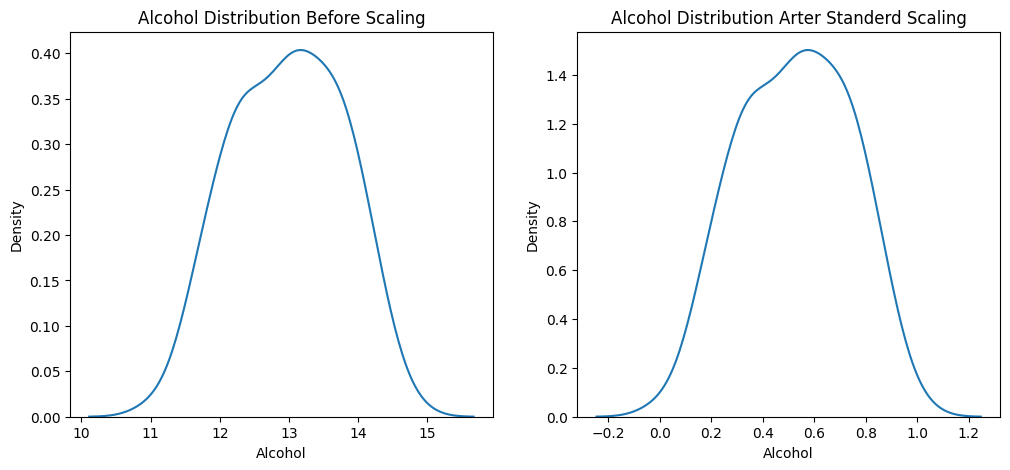

In [44]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Alcohol Distribution Before Scaling')
sns.kdeplot(X_train['Alcohol'],ax=ax1)

# after scaling
ax2.set_title('Alcohol Distribution Arter Standerd Scaling')
sns.kdeplot(X_train_scaled['Alcohol'], ax=ax2)

plt.show()


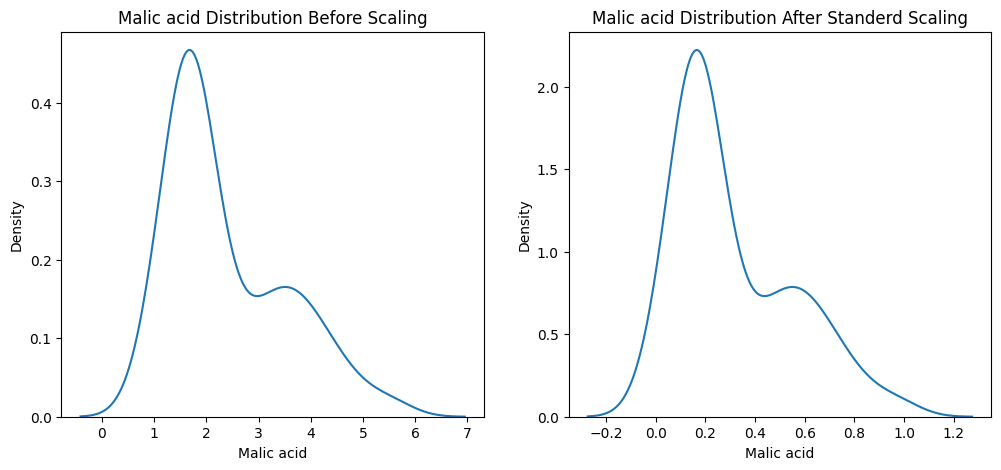

In [45]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Malic acid Distribution Before Scaling')
sns.kdeplot(X_train['Malic acid'], ax=ax1)

# after scaling
ax2.set_title('Malic acid Distribution After Standerd Scaling')
sns.kdeplot(X_train_scaled['Malic acid'], ax=ax2)

plt.show()
